## Importing the Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

## Loading the Dataset

In [4]:
df = pd.read_csv('Mall_Customers.csv.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Basic Info on the Dataset

In [6]:
df.shape

(200, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
x = df.iloc[:,3:]
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


### Encoding the Data

In [11]:
encoded_df = pd.get_dummies(df, drop_first = True, dtype = 'int')
encoded_df

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0
...,...,...,...,...,...
195,196,35,120,79,0
196,197,45,126,28,0
197,198,32,126,74,1
198,199,32,137,18,1


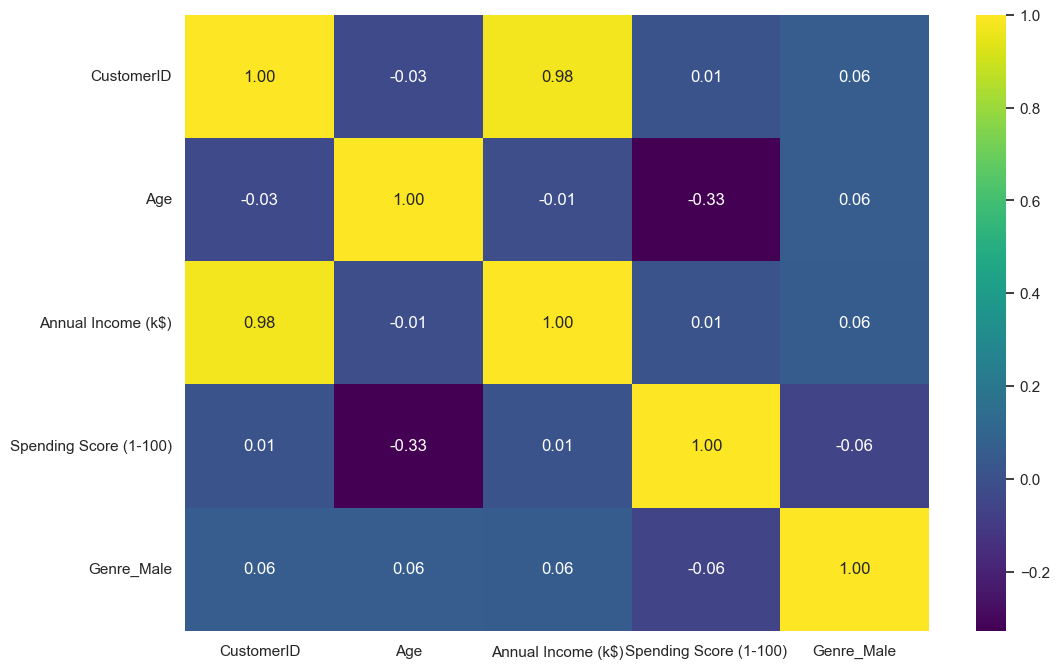

In [12]:
plt.figure(figsize = (12, 8))
sns.heatmap(encoded_df.corr(), annot = True, fmt = '.2f', cmap = 'viridis')
plt.show()

Since Customer ID and Annual Income have a High Correlation, we will drop the Customer ID Column from the dataset

## K-Means Clustering

In [15]:
from sklearn.cluster import KMeans

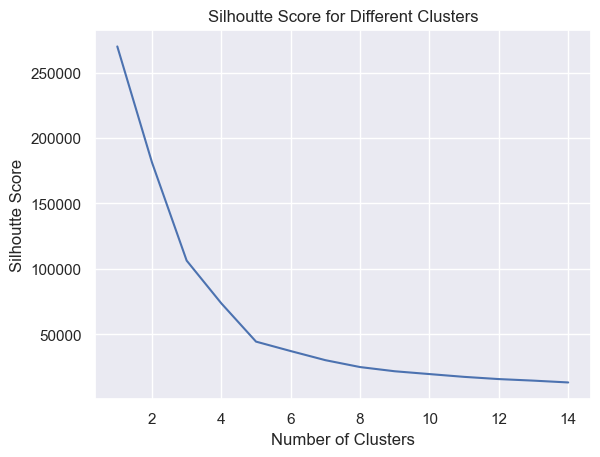

In [16]:
ss = []
for i in range(1,15):
    model = KMeans(n_clusters = i, init = 'k-means++', max_iter = 500, n_init = 10)
    model.fit(x)
    ss.append(model.inertia_)

plt.plot(range(1,15), ss)
plt.xlabel('Number of Clusters')
plt.ylabel('Silhoutte Score')
plt.title('Silhoutte Score for Different Clusters')
plt.show()

In [17]:
ss

[269981.28,
 181363.59595959593,
 106348.37306211122,
 73679.78903948836,
 44448.4554479337,
 37233.814510710006,
 30273.394312070042,
 25007.38394731205,
 21797.08494464637,
 19649.596582866958,
 17518.64345656769,
 15825.497593206394,
 14638.827459198455,
 13253.332364857364]

We see that the silhoutte score stabilizes after the 6th CLuster, therefore, we will choose no of clusters = 6

In [19]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 500, n_init = 10)
y_kmeans = kmeans.fit_predict(x)

In [20]:
kmeans.inertia_

44448.4554479337

In [21]:
y_kmeans

array([2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 0,
       2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 3, 0, 3, 1, 3, 1, 3,
       0, 3, 1, 3, 1, 3, 1, 3, 1, 3, 0, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3])

In [22]:
combined_df = pd.concat([df, pd.DataFrame(y_kmeans, columns = ['Class'])], axis = 1)
combined_df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Class
0,1,Male,19,15,39,2
1,2,Male,21,15,81,4
2,3,Female,20,16,6,2
3,4,Female,23,16,77,4
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,1
197,198,Male,32,126,74,3
198,199,Male,32,137,18,1


### Visualizing the Cluster

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

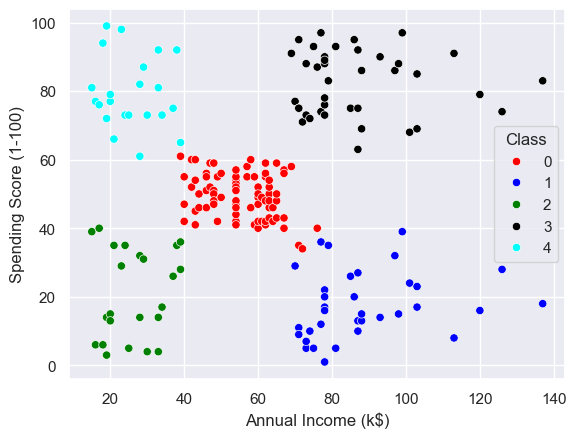

In [24]:
sns.scatterplot(data = combined_df, x = combined_df['Annual Income (k$)'], y = combined_df['Spending Score (1-100)'], hue = 'Class',
                palette = ['red', 'blue', 'green', 'black', 'cyan'])

# Hierarchical Clustering

In [26]:
import scipy.cluster.hierarchy as sch

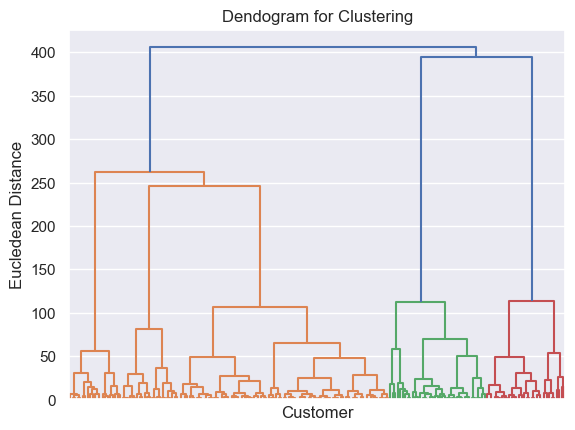

In [27]:
dendrogram = sch.dendrogram(sch.linkage(x, method = 'ward'))
plt.title('Dendogram for Clustering')
plt.ylabel('Eucledean Distance')
plt.xticks(ticks = [])
plt.xlabel('Customer')
plt.show()

In [47]:
from sklearn.cluster import AgglomerativeClustering

In [55]:
hc = AgglomerativeClustering(n_clusters = 5, linkage = 'ward')
hc

AgglomerativeClustering(n_clusters=5)

In [57]:
y_hc = hc.fit_predict(x)
y_hc

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2], dtype=int64)

In [59]:
merged_df = pd.concat([df, pd.DataFrame(y_hc, columns = ['Cluster'])], axis = 1)
merged_df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,2
196,197,Female,45,126,28,0
197,198,Male,32,126,74,2
198,199,Male,32,137,18,0


### Visualizing the Clusters

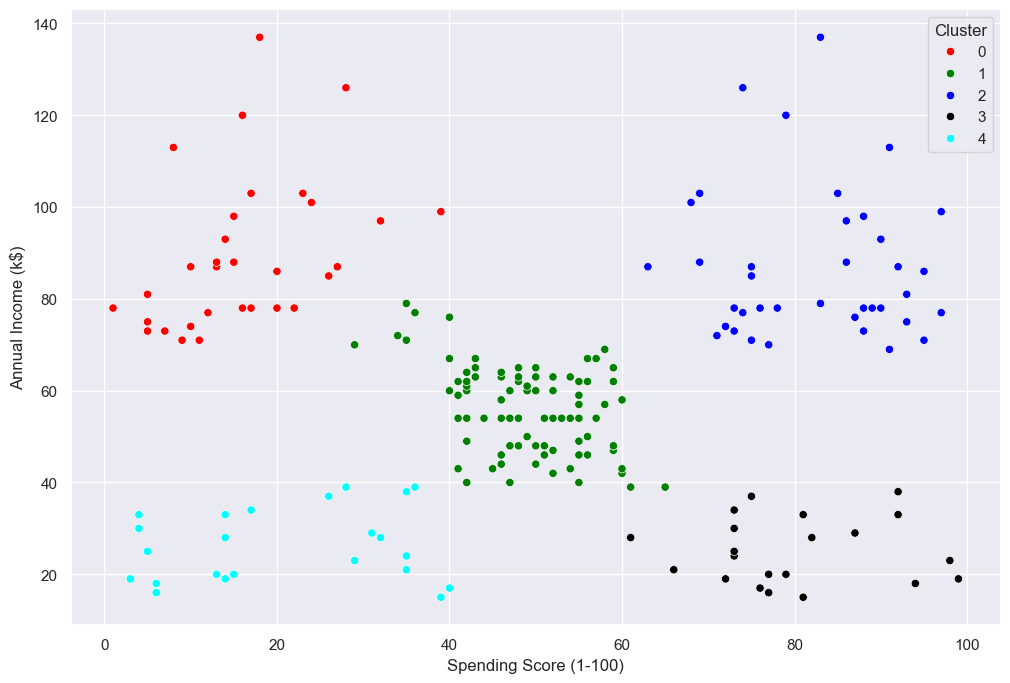

In [62]:
plt.figure(figsize = (12, 8))
sns.scatterplot(data = merged_df, y = 'Annual Income (k$)', x = 'Spending Score (1-100)', hue = 'Cluster',
                palette = ['red', 'green', 'blue', 'black', 'cyan'])
plt.show()